In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [4]:
import os

BASE = '/kaggle/input/datasets/vijuls/pupildiameterdatasets'
print("Path exists:", os.path.exists(BASE))

for root, dirs, files in os.walk(BASE):
    dirs[:] = sorted(dirs)
    level = root.replace(BASE, "").count(os.sep)
    if level > 3: continue
    indent = "    " * level + "├── "
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files)[:3]:
        print(f"{'    '*(level+1)}├── {f}")
    if len(files) > 3:
        print(f"{'    '*(level+1)}└── ... {len(files)-3} more files")

Path exists: True
├── pupildiameterdatasets/
    ├── eyedentify/
        ├── eyedentify/
            ├── data_distribution/
            ├── left_eyes/
            ├── left_eyes_depth_maps/
            ├── right_eyes/
            ├── right_eyes_depth_maps/
    ├── eyedentifySR/
        ├── eyedentify++/
            ├── CodeFormer_x2/


KeyboardInterrupt: 

In [5]:
import os, cv2, random
import matplotlib.pyplot as plt

BASE = '/kaggle/input/datasets/vijuls/pupildiameterdatasets/eyedentify/eyedentify'

LEFT  = os.path.join(BASE, 'left_eyes')
RIGHT = os.path.join(BASE, 'right_eyes')

print("Left eyes path exists :", os.path.exists(LEFT))
print("Right eyes path exists:", os.path.exists(RIGHT))

Left eyes path exists : True
Right eyes path exists: True


In [6]:
ext = {".jpg", ".jpeg", ".png"}

for split_name, split_path in [("Left Eyes", LEFT), ("Right Eyes", RIGHT)]:
    subjects = sorted(os.listdir(split_path))
    total = 0
    print(f"=== {split_name} ===")
    print(f"Total subjects: {len(subjects)}")
    for s in subjects[:5]:
        s_path = os.path.join(split_path, s)
        if not os.path.isdir(s_path): continue
        count = sum(1 for f in os.listdir(s_path)
                    if os.path.splitext(f)[1].lower() in ext)
        print(f"  {s} → {count} images")
        total += count
    print(f"  ... and {len(subjects)-5} more subjects")
    print(f"  TOTAL → {total} images (first 5 subjects)\n")

=== Left Eyes ===
Total subjects: 51
  1 → 0 images
  10 → 0 images
  11 → 0 images
  12 → 0 images
  13 → 0 images
  ... and 46 more subjects
  TOTAL → 0 images (first 5 subjects)

=== Right Eyes ===
Total subjects: 51
  1 → 0 images
  10 → 0 images
  11 → 0 images
  12 → 0 images
  13 → 0 images
  ... and 46 more subjects
  TOTAL → 0 images (first 5 subjects)



In [7]:
import os

# check what's inside subject "1"
subject_path = '/kaggle/input/datasets/vijuls/pupildiameterdatasets/eyedentify/eyedentify/left_eyes/1'

print("=== Inside subject 1 ===")
for root, dirs, files in os.walk(subject_path):
    level = root.replace(subject_path, "").count(os.sep)
    if level > 2: continue
    indent = "    " * level + "├── "
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files)[:3]:
        print(f"{'    '*(level+1)}├── {f}")
    if len(files) > 3:
        print(f"{'    '*(level+1)}└── ... {len(files)-3} more files")



=== Inside subject 1 ===
├── 1/
    ├── 7/
        ├── frame_01.png
        ├── frame_02.png
        ├── frame_03.png
        └── ... 87 more files
    ├── 47/
        ├── frame_01.png
        ├── frame_02.png
        ├── frame_03.png
        └── ... 87 more files
    ├── 17/
        ├── frame_01.png
        ├── frame_02.png
        ├── frame_03.png
        └── ... 87 more files
    ├── 19/
        ├── frame_03.png
        ├── frame_04.png
        ├── frame_06.png
        └── ... 73 more files
    ├── 22/
        ├── frame_01.png
        ├── frame_02.png
        ├── frame_03.png
        └── ... 87 more files
    ├── 2/
        ├── frame_01.png
        ├── frame_02.png
        ├── frame_03.png
        └── ... 87 more files
    ├── 35/
        ├── frame_01.png
        ├── frame_02.png
        ├── frame_03.png
        └── ... 86 more files
    ├── 50/
        ├── frame_01.png
        ├── frame_02.png
        ├── frame_03.png
        └── ... 87 more files
    ├── 23/
        ├── frame_01.p

In [8]:
import os

ext = {".jpg", ".jpeg", ".png"}

for split_name, split_path in [("Left Eyes", LEFT), ("Right Eyes", RIGHT)]:
    subjects = sorted(os.listdir(split_path))
    total_images = 0
    total_sessions = 0
    print(f"=== {split_name} ===")
    print(f"Total subjects: {len(subjects)}")
    
    for s in subjects[:5]:
        s_path = os.path.join(split_path, s)
        if not os.path.isdir(s_path): continue
        sessions = os.listdir(s_path)
        imgs = sum(
            1 for ses in sessions
            for f in os.listdir(os.path.join(s_path, ses))
            if os.path.splitext(f)[1].lower() in ext
        )
        print(f"  Subject {s} → {len(sessions)} sessions, {imgs} images")
        total_images  += imgs
        total_sessions += len(sessions)

    # count all subjects
    all_images = sum(
        1 for s in subjects
        for ses in os.listdir(os.path.join(split_path, s))
        for f in os.listdir(os.path.join(split_path, s, ses))
        if os.path.splitext(f)[1].lower() in ext
    )
    print(f"  TOTAL → {all_images:,} images across {len(subjects)} subjects\n")

=== Left Eyes ===
Total subjects: 51
  Subject 1 → 50 sessions, 4437 images
  Subject 10 → 50 sessions, 4356 images
  Subject 11 → 50 sessions, 4048 images
  Subject 12 → 50 sessions, 4220 images
  Subject 13 → 50 sessions, 4365 images
  TOTAL → 212,073 images across 51 subjects

=== Right Eyes ===
Total subjects: 51
  Subject 1 → 50 sessions, 4437 images
  Subject 10 → 50 sessions, 4356 images
  Subject 11 → 50 sessions, 4048 images
  Subject 12 → 50 sessions, 4220 images
  Subject 13 → 50 sessions, 4365 images
  TOTAL → 212,073 images across 51 subjects



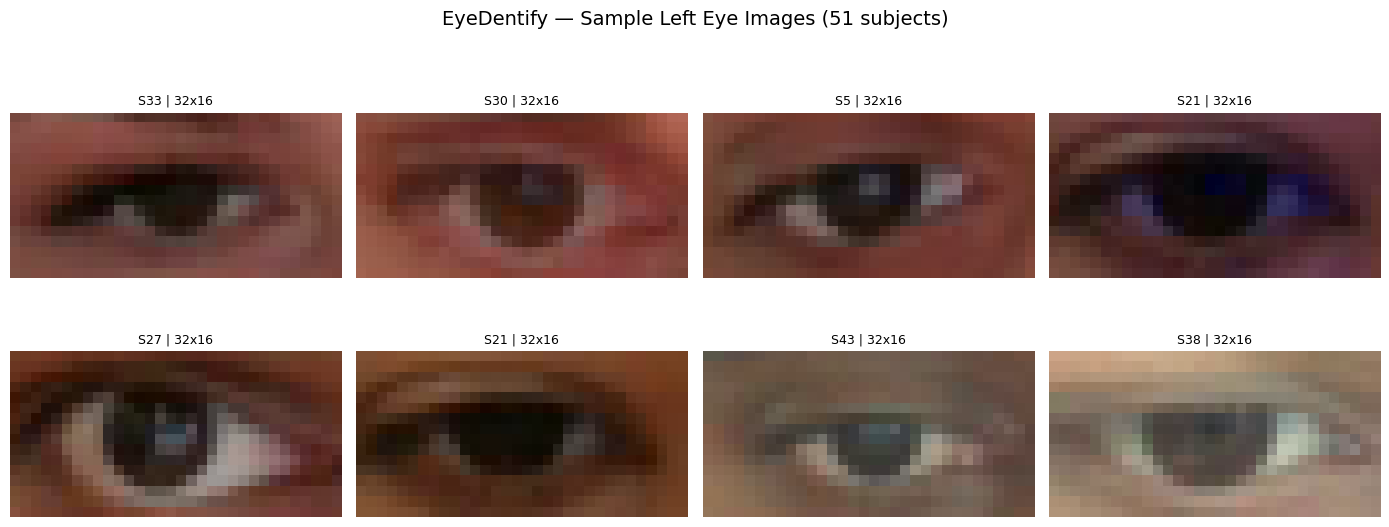

✓ Done


In [9]:
import cv2, random
import matplotlib.pyplot as plt

all_images = []
for s in os.listdir(LEFT):
    s_path = os.path.join(LEFT, s)
    if not os.path.isdir(s_path): continue
    for ses in os.listdir(s_path):
        ses_path = os.path.join(s_path, ses)
        if not os.path.isdir(ses_path): continue
        for f in os.listdir(ses_path):
            if os.path.splitext(f)[1].lower() in ext:
                all_images.append((s, os.path.join(ses_path, f)))

samples = random.sample(all_images, min(8, len(all_images)))

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("EyeDentify — Sample Left Eye Images (51 subjects)", fontsize=14)

for ax, (subject, path) in zip(axes.flat, samples):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"S{subject} | {img.shape[1]}x{img.shape[0]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()
print("✓ Done")

In [10]:
print("=" * 45)
print("   EYEDENTIFY EXPLORATION SUMMARY")
print("=" * 45)
print()
print("Dataset → EyeDentify")
print("  Subjects     : 51")
print("  Structure    : subject → session → frames")
print("  Eyes         : left + right separately")
print("  Format       : frame_01.png, frame_02.png...")
print("  Labels       : pupil diameter per frame")
print()
print("Use in project:")
print("  Week 2 → pupil movement extraction")
print("  Week 3 → CNN + LSTM training (51 users!)")
print()
print("✓ EyeDentify exploration complete!")
print("✓ All 4 datasets explored — Week 1 complete!")

   EYEDENTIFY EXPLORATION SUMMARY

Dataset → EyeDentify
  Subjects     : 51
  Structure    : subject → session → frames
  Eyes         : left + right separately
  Format       : frame_01.png, frame_02.png...
  Labels       : pupil diameter per frame

Use in project:
  Week 2 → pupil movement extraction
  Week 3 → CNN + LSTM training (51 users!)

✓ EyeDentify exploration complete!
✓ All 4 datasets explored — Week 1 complete!
